In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv("Food_Delivery_Times.csv")

In [8]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [9]:
df.shape

(1000, 9)

In [11]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [12]:
print('Original DataFrame shape:', df.shape)

# Impute missing categorical values with the mode
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

# Impute missing numerical value 'Courier_Experience_yrs' with the mean
if df['Courier_Experience_yrs'].isnull().any():
    df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean(), inplace=True)

# Drop the 'Order_ID' column
df.drop('Order_ID', axis=1, inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print('\nMissing values after imputation and column drop:')
display(df.isnull().sum())
print('\nDataFrame shape after processing:', df.shape)
display(df.head())

Original DataFrame shape: (1000, 9)

Missing values after imputation and column drop:


,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0



DataFrame shape after processing: (1000, 8)


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


### Exploratory Data Analysis (EDA) of Target Variable: `Delivery_Time_min`

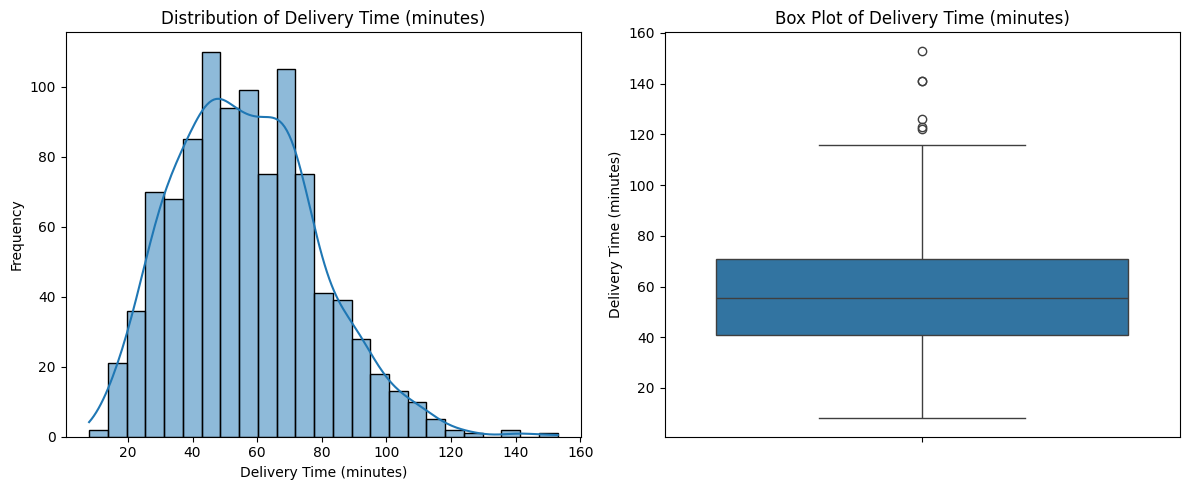

In [13]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['Delivery_Time_min'], kde=True)
plt.title('Distribution of Delivery Time (minutes)')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Delivery_Time_min'])
plt.title('Box Plot of Delivery Time (minutes)')
plt.ylabel('Delivery Time (minutes)')

plt.tight_layout()
plt.show()

In [14]:
print("Descriptive Statistics for Delivery_Time_min:")
display(df['Delivery_Time_min'].describe())

Descriptive Statistics for Delivery_Time_min:


,Delivery_Time_min
count,1000.000000
mean,56.732000
std,22.070915
min,8.000000
25%,41.000000
50%,55.500000
75%,71.000000
max,153.000000


### Bivariate Analysis: Relationship between Features and `Delivery_Time_min`

#### Categorical Features vs. `Delivery_Time_min`

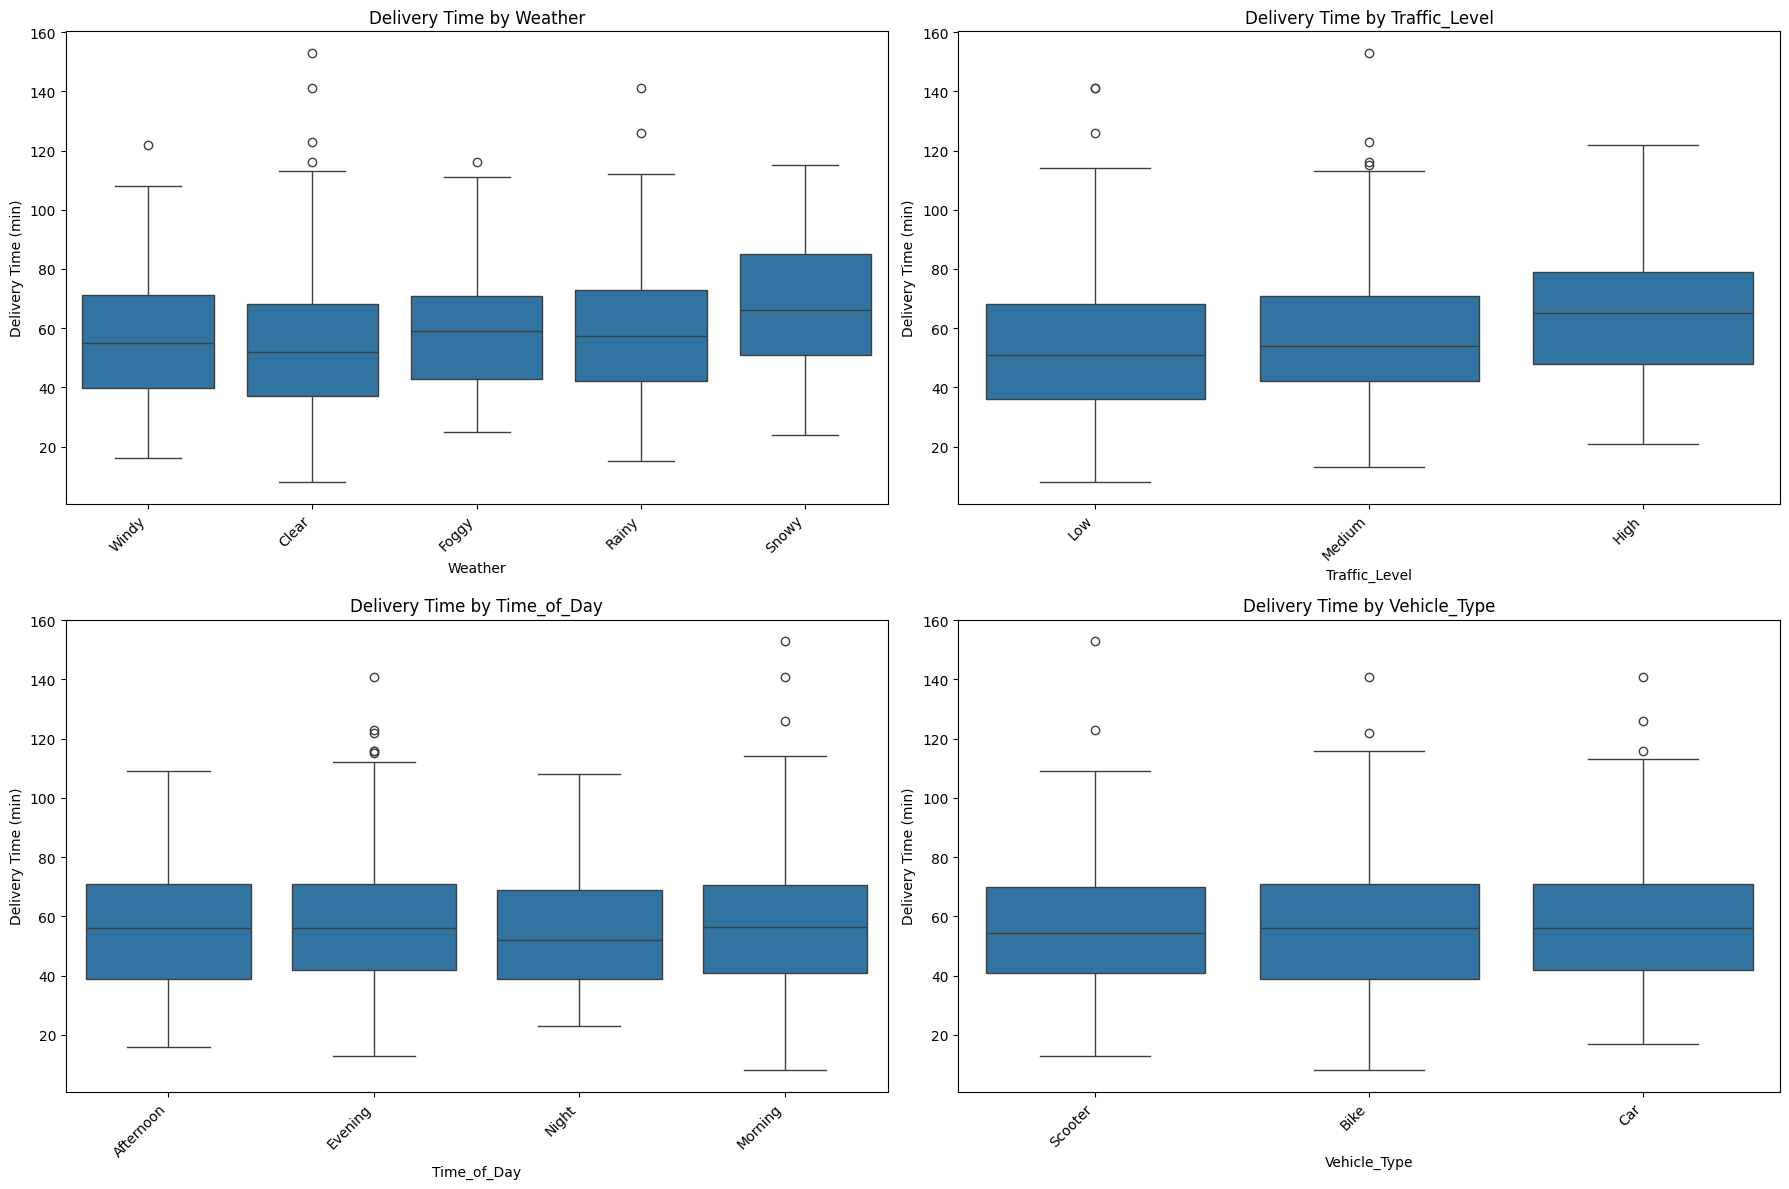

In [15]:
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=col, y='Delivery_Time_min', data=df)
    plt.title(f'Delivery Time by {col}')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (min)')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Numerical Features vs. `Delivery_Time_min`

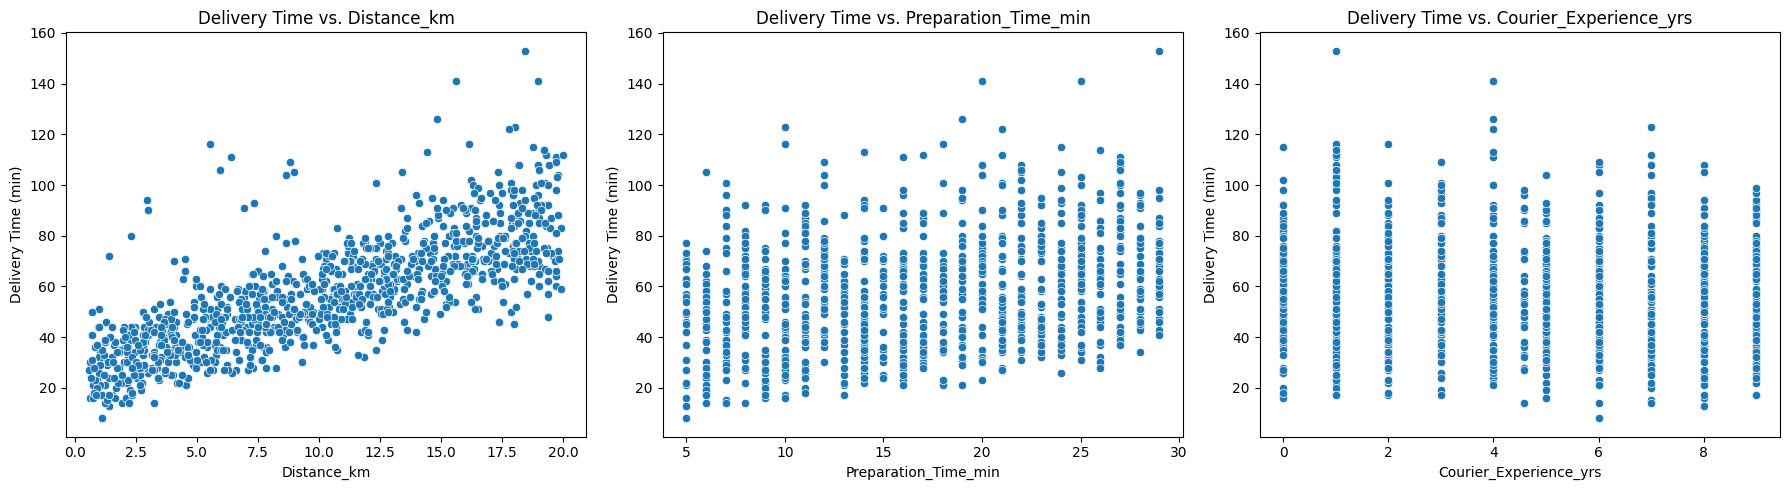

In [16]:
numerical_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

plt.figure(figsize=(18, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=col, y='Delivery_Time_min', data=df)
    plt.title(f'Delivery Time vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (min)')
plt.tight_layout()
plt.show()

In [17]:
print("Correlation Matrix with Delivery_Time_min:")
display(df[numerical_cols + ['Delivery_Time_min']].corr()[['Delivery_Time_min']].drop('Delivery_Time_min'))

Correlation Matrix with Delivery_Time_min:


,Delivery_Time_min
Distance_km,0.780998
Preparation_Time_min,0.307350
Courier_Experience_yrs,-0.089066


### Statistical Testing for Feature Selection

#### ANOVA for Categorical Features

In [20]:
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.anova import anova_lm

# Perform ANOVA for each categorical feature
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

print("ANOVA Test Results for Categorical Features:")
for col in categorical_cols:
    # Create a formula string for ANOVA
    formula = f'Delivery_Time_min ~ C({col})'
    model = smf.ols(formula, data=df).fit()
    anova_table = anova_lm(model, typ=2)
    p_value = anova_table['PR(>F)'][0]
    print(f"\nFeature: {col}")
    print(f"P-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"  -> {col} is statistically significant (p < 0.05)")
    else:
        print(f"  -> {col} is not statistically significant (p >= 0.05)")

ANOVA Test Results for Categorical Features:

Feature: Weather
P-value: 0.0000
  -> Weather is statistically significant (p < 0.05)

Feature: Traffic_Level
P-value: 0.0000
  -> Traffic_Level is statistically significant (p < 0.05)

Feature: Time_of_Day
P-value: 0.7915
  -> Time_of_Day is not statistically significant (p >= 0.05)

Feature: Vehicle_Type
P-value: 0.5549
  -> Vehicle_Type is not statistically significant (p >= 0.05)


#### Pearson Correlation with P-values for Numerical Features

In [21]:
numerical_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

print("Pearson Correlation and P-values with Delivery_Time_min:")
correlation_results = []
for col in numerical_cols:
    corr, p_value = stats.pearsonr(df[col], df['Delivery_Time_min'])
    correlation_results.append({
        'Feature': col,
        'Pearson Correlation': corr,
        'P-value': p_value,
        'Significant (p<0.05)': 'Yes' if p_value < 0.05 else 'No'
    })

display(pd.DataFrame(correlation_results))

Pearson Correlation and P-values with Delivery_Time_min:


,Feature,Pearson Correlation,P-value,Significant (p<0.05)
0,Distance_km,0.780998,2.976269e-206,Yes
1,Preparation_Time_min,0.307350,2.549879e-23,Yes
2,Courier_Experience_yrs,-0.089066,4.823205e-03,Yes


### Label Encoding for Categorical Features

In [22]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns to encode (excluding 'Delivery_Time_min' and any numerical features)
categorical_cols_to_encode = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

# Create a copy of the DataFrame to store encoded values
df_encoded = df.copy()

# Apply Label Encoding to each categorical column
label_encoders = {}
for col in categorical_cols_to_encode:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le # Store the encoder for potential inverse transformation or inspection

print("DataFrame after Label Encoding:")
display(df_encoded.head())
print("\nOriginal vs Encoded values (example for 'Weather' column):")
# Display mapping for one column as an example
for label, original in zip(label_encoders['Weather'].transform(label_encoders['Weather'].classes_), label_encoders['Weather'].classes_):
    print(f"Original: {original}, Encoded: {label}")

DataFrame after Label Encoding:


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68



Original vs Encoded values (example for 'Weather' column):
Original: Clear, Encoded: 0
Original: Foggy, Encoded: 1
Original: Rainy, Encoded: 2
Original: Snowy, Encoded: 3
Original: Windy, Encoded: 4


### Splitting the Dataset into Features (X) and Target (y)

In [23]:
# Define features (X) and target (y)
X = df_encoded.drop('Delivery_Time_min', axis=1)
y = df_encoded['Delivery_Time_min']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
display(X.head())

Features (X) shape: (1000, 7)
Target (y) shape: (1000,)


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
0,7.93,4,1,0,2,12,1.0
1,16.42,0,2,1,0,20,2.0
2,9.52,1,1,3,2,28,1.0
3,7.44,2,2,0,2,5,1.0
4,19.03,0,1,2,0,16,5.0


### Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% train, 20% test

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 7)
X_test shape: (200, 7)
y_train shape: (800,)
y_test shape: (200,)


### Building a Decision Tree Regressor Model

In [25]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor with default parameters
decision_tree_model = DecisionTreeRegressor(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Regressor model trained successfully with default parameters.")
# Make predictions on the test data
y_pred_dt = decision_tree_model.predict(X_test)

Decision Tree Regressor model trained successfully with default parameters.


### Evaluating the Decision Tree Regressor Model

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_dt)
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dt)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 10.52
Mean Squared Error (MSE): 226.84
Root Mean Squared Error (RMSE): 15.06
R-squared (R2): 0.49


### Building a Random Forest Regressor Model

In [27]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor with default parameters
random_forest_model = RandomForestRegressor(random_state=42)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully with default parameters.")
y_pred = random_forest_model.predict(X_test)

Random Forest Regressor model trained successfully with default parameters.


### Evaluating the Random Forest Regressor Model

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics for Random Forest
mae_rf = mean_absolute_error(y_test, y_pred)
mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred)

print(f"Random Forest - Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Random Forest - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest - Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"Random Forest - R-squared (R2): {r2_rf:.2f}")

Random Forest - Mean Absolute Error (MAE): 7.11
Random Forest - Mean Squared Error (MSE): 100.34
Random Forest - Root Mean Squared Error (RMSE): 10.02
Random Forest - R-squared (R2): 0.78


### Hyperparameter Tuning for Random Forest Regressor

In [31]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint

# Define the parameter distribution for Random Forest
param_dist = {
    'n_estimators': randint(100,1001),# Number of trees in the forest
    'max_features': ['auto', 'sqrt', 'log2', None],  # Number of features to consider at each split
    'max_depth': randint(5,31),   # Maximum depth of the tree
    'min_samples_split': randint(2,21),   # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1,11)     # Minimum number of samples required to be at a leaf node
}

# Initialize RandomizedSearchCV
# Using n_jobs=-1 to utilize all available CPU cores for faster computation
# n_iter specifies the number of parameter settings that are sampled
random_search = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42),
                                   param_distributions=param_dist,
                                   n_iter=100,             # Number of parameter settings that are sampled
                                   cv=5,                  # 5-fold cross-validation
                                   scoring='neg_mean_squared_error', # Optimize for MSE
                                   n_jobs=-1,             # Use all available cores
                                   verbose=1,
                                   random_state=42)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("Best parameters found:", random_search.best_params_)
print("Best MSE score found (negative):", random_search.best_score_)
print("Best RMSE score found:", (-random_search.best_score_)**0.5)

# Get the best model
best_random_forest_model = random_search.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters found: {'max_depth': 16, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 12, 'n_estimators': 739}
Best MSE score found (negative): -144.5691003061732
Best RMSE score found: 12.023689130469617


### Evaluating the Hyperparameter-Tuned Random Forest Regressor Model

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions using the best model
y_pred_tuned_rf = best_random_forest_model.predict(X_test)

# Calculate evaluation metrics for the tuned Random Forest model
mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
rmse_tuned_rf = np.sqrt(mse_tuned_rf)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print(f"Tuned Random Forest - Mean Absolute Error (MAE): {mae_tuned_rf:.2f}")
print(f"Tuned Random Forest - Mean Squared Error (MSE): {mse_tuned_rf:.2f}")
print(f"Tuned Random Forest - Root Mean Squared Error (RMSE): {rmse_tuned_rf:.2f}")
print(f"Tuned Random Forest - R-squared (R2): {r2_tuned_rf:.2f}")

Tuned Random Forest - Mean Absolute Error (MAE): 6.87
Tuned Random Forest - Mean Squared Error (MSE): 97.21
Tuned Random Forest - Root Mean Squared Error (RMSE): 9.86
Tuned Random Forest - R-squared (R2): 0.78


### Saving the Label Encoders and Best Model as Pickle Files

In [33]:
import pickle

# Save the label_encoders dictionary
with open('label_encoders.pkl', 'wb') as file:
    pickle.dump(label_encoders, file)
print("label_encoders saved to 'label_encoders.pkl'")

# Save the best_random_forest_model
with open('best_random_forest_model.pkl', 'wb') as file:
    pickle.dump(best_random_forest_model, file)
print("best_random_forest_model saved to 'best_random_forest_model.pkl'")

label_encoders saved to 'label_encoders.pkl'
best_random_forest_model saved to 'best_random_forest_model.pkl'
